In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
from data_loader import load_weekly_data, load_supplementary
input_data, output_data = load_weekly_data()

In [4]:
# Clean tracking data
# Clean orientation and direction
input_data["o_clean"] = (-(input_data["o"] - 90)) % 360
input_data["dir_clean"] = (-(input_data["dir"] - 90)) % 360
# Set x on same scale
input_data["x_clean"] = np.where(
      input_data["play_direction"] == "left",
      120 - input_data["x"],
      input_data[
          "x"
      ], 
  )
# y, s, a alreday clean
input_data["y_clean"] = input_data["y"]
input_data["s_clean"] = input_data["s"]
input_data["a_clean"] = input_data["a"]
# Clean orientation based on play direction
input_data["o_clean"] = np.where(
    input_data["play_direction"] == "left", 180 - input_data["o_clean"], input_data["o_clean"]
)
# Clean orientation, direction, vx, and vy
input_data["o_clean"] = (input_data["o_clean"] + 360) % 360 
input_data["dir_clean"] = (input_data["dir_clean"] + 360) % 360
input_data["dir_radians"] = np.radians(input_data["dir_clean"])
input_data["v_x"] = input_data["s_clean"] * np.cos(input_data["dir_radians"])
input_data["v_y"] = input_data["s_clean"] * np.sin(input_data["dir_radians"])

# Add in previous location
input_data["prev_x"] = input_data["x_clean"].shift(1)
input_data["prev_y"] = input_data["y_clean"].shift(1)
# Remove NAs
input_data = input_data.dropna()

In [5]:
input_data.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,wk,o_clean,dir_clean,x_clean,y_clean,s_clean,a_clean,dir_radians,v_x,v_y
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,1,211.76,127.60,52.33,36.94,0.09,0.39,2.227040,-0.054913,0.071306
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,1,213.95,249.11,52.33,36.94,0.04,0.61,4.347790,-0.014263,-0.037371
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,1,209.40,302.45,52.33,36.93,0.12,0.73,5.278748,0.064388,-0.101263
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,1,205.75,318.60,52.35,36.92,0.23,0.81,5.560619,0.172526,-0.152102
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,1,205.75,326.74,52.37,36.90,0.35,0.82,5.702689,0.292667,-0.191954


In [6]:
input_data["player_side"].value_counts()

player_side
Defense    2662657
Offense    2217922
Name: count, dtype: int64

In [7]:
input_data.columns

Index(['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id',
       'play_direction', 'absolute_yardline_number', 'player_name',
       'player_height', 'player_weight', 'player_birth_date',
       'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a',
       'dir', 'o', 'num_frames_output', 'ball_land_x', 'ball_land_y', 'wk',
       'o_clean', 'dir_clean', 'x_clean', 'y_clean', 's_clean', 'a_clean',
       'dir_radians', 'v_x', 'v_y'],
      dtype='object')

## PCA

In [5]:
# 
offense = input_data[input_data['player_side'] == 'Offense'].copy()

pre_snap = offense.loc[offense.groupby(['game_id', 'play_id', 'nfl_id'])['frame_id'].idxmin()]

feature_columns = ["x_clean", "y_clean", "s_clean", "a_clean", "o_clean", "dir_clean", "v_x", "v_y"]

X = pre_snap[feature_columns].values


In [9]:
offense.head()

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,wk,o_clean,dir_clean,x_clean,y_clean,s_clean,a_clean,dir_radians,v_x,v_y
130,2023090700,101,False,53541,1,right,42,Amon-Ra St. Brown,6-1,195,...,1,15.28,359.30,40.61,19.12,0.00,0.00,6.270968,0.000000,-0.000000
131,2023090700,101,False,53541,2,right,42,Amon-Ra St. Brown,6-1,195,...,1,14.39,1.66,40.61,19.12,0.00,0.00,0.028972,0.000000,0.000000
132,2023090700,101,False,53541,3,right,42,Amon-Ra St. Brown,6-1,195,...,1,13.35,14.58,40.62,19.12,0.02,0.38,0.254469,0.019356,0.005035
133,2023090700,101,False,53541,4,right,42,Amon-Ra St. Brown,6-1,195,...,1,13.35,10.32,40.63,19.12,0.16,1.38,0.180118,0.157412,0.028663
134,2023090700,101,False,53541,5,right,42,Amon-Ra St. Brown,6-1,195,...,1,9.99,0.65,40.67,19.12,0.48,3.08,0.011345,0.479969,0.005445


In [6]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),  
    ('kmeans', KMeans(n_clusters=8, n_init=10, random_state=42))
])

pipe.fit(X)

pca = pipe.named_steps['pca']

labels = pipe.named_steps['kmeans'].labels_
pre_snap["cluster"] = labels

# stats

print("PCA Components:", pca.n_components_)
print("Explained variance (ratio):", pca.explained_variance_ratio_)
print("Cluster counts:\n", pre_snap["cluster"].value_counts())

explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)
n_components = len(explained_var)

df_pca = pd.DataFrame({
    "PC": np.arange(1, n_components + 1),
    "ExplainedVariance": explained_var,
    "CumulativeVariance": cum_explained_var
})

fig_scree = px.line(
    df_pca, x="PC", y="ExplainedVariance",
    markers=True,
    title="Scree Plot: Proportion of Variance Explained"
)
fig_scree.show()


PCA Components: 8
Explained variance (ratio): [0.17974374 0.1521004  0.1369034  0.12500335 0.12417982 0.11298002
 0.09809769 0.07099157]
Cluster counts:
 cluster
7    18315
1    17991
6    17553
0    16932
5     3134
3     2699
2     1142
4     1091
Name: count, dtype: int64


In [12]:
X_pca_scores = pipe.transform(X)
pc_cols = [f"PC{i}" for i in range(1, n_components + 1)]

scores_df = pd.DataFrame(X_pca_scores, columns=pc_cols)
scores_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
0,2.526388,3.042890,8.686848,4.337289,8.537013,4.170589,2.551280,0.916999
1,2.836706,1.561991,8.628385,4.353104,8.715889,4.323299,2.496230,3.246269
2,2.548612,1.915123,8.568152,4.335178,8.760650,4.305201,2.291680,3.350511
3,1.222797,3.003656,8.422716,4.232956,8.765602,4.142712,2.317131,2.385641
4,1.600632,2.772380,8.447433,4.128428,8.625145,4.015076,2.302506,1.468332
...,...,...,...,...,...,...,...,...
78852,2.640156,2.494817,8.710182,4.324244,8.505195,4.178887,1.393673,2.740367
78853,6.331478,6.547909,2.630496,5.548919,9.975604,5.870553,6.738273,6.598934
78854,0.911296,2.464571,8.407539,4.017577,8.543585,3.892857,2.180848,1.322772
78855,1.864233,2.608494,8.555379,4.155244,8.502038,4.005211,2.480189,0.828169


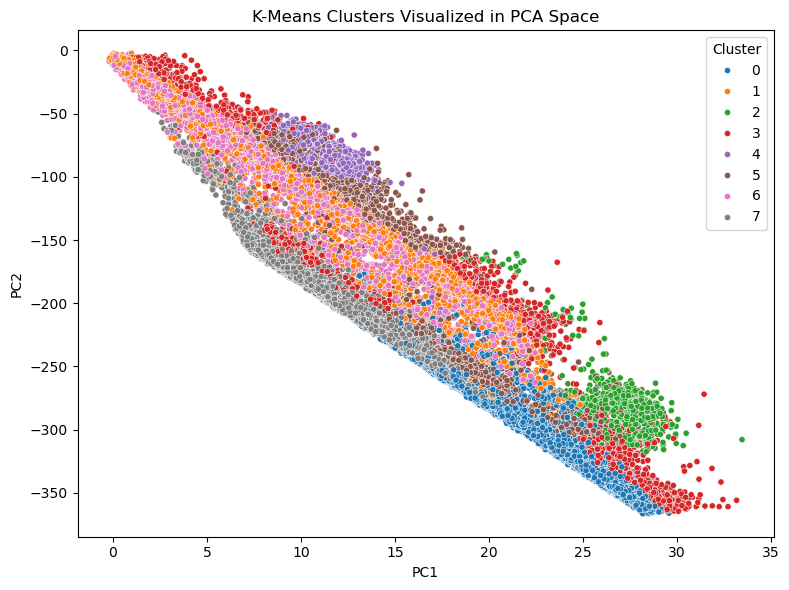

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=labels
)
plt.title("K-Means Clusters Visualized in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [11]:
cluster_summary = pre_snap.groupby("cluster")[feature_columns].mean()
cluster_summary

,x_clean,y_clean,s_clean,a_clean,o_clean,dir_clean,v_x,v_y
cluster,,,,,,,,
0,59.665639,28.735615,0.051120,0.202791,341.380896,273.490275,0.004669,-0.028023
1,63.156229,18.213343,0.049528,0.215758,24.734180,185.247564,-0.000016,-0.000453
2,53.931357,25.841471,6.012198,1.548678,274.317452,269.705377,-0.029775,-5.979709
3,53.976258,25.981445,0.771878,2.015695,181.840422,193.745587,0.410923,-0.048393
4,54.394592,27.798469,6.002887,1.545435,84.256022,90.170403,-0.021253,5.974146
5,53.498197,27.062387,0.745466,1.937562,183.127144,178.774234,-0.404385,0.026617
6,45.411322,33.124547,0.049561,0.193242,19.501352,174.747006,0.000113,0.003835
7,49.386815,27.497669,0.048304,0.209720,341.360644,91.628314,0.000751,0.022882


In [13]:
from sklearn.metrics import silhouette_score

sil_scores = []
K_values_sil = list(range(2, 11))

for k in K_values_sil:
    pipe.set_params(kmeans__n_clusters=k)
    pipe.fit(X)

    labels = pipe["kmeans"].labels_

    sil = silhouette_score(X, labels)

    sil_scores.append(sil)

In [17]:
sil_scores

[0.5964978431860586,
 0.36080922265480636,
 0.05239384080925968,
 -0.0571828683878478,
 -0.0947305229725968,
 -0.11846299745992692,
 0.04473713307336704,
 -0.0375102166841824,
 -0.022241919935220615]

In [ ]:


lines = list(range(2, 11))
fig = px.line(
    x=lines,
    y=sil_scores,
    markers=True,
    title="Silhouette Scores (Pipeline: StandardScaler + KMeans)",
    labels={"x": "Number of Clusters (K)", "y": "Silhouette Score"}
)

fig.update_layout(height=500, width=700)
fig.show()

In [16]:
# Elbow 

K_values = list(range(1, 11))
wcss = []

for k in K_values:
    pipe.set_params(kmeans__n_clusters=k)
    pipe.fit(X)
    inertia = pipe["kmeans"].inertia_
    wcss.append(inertia)


fig = px.line(
    x=K_values,
    y=wcss,
    markers=True,
    title="Elbow Plot (Pipeline: StandardScaler + KMeans)",
    labels={"x": "Number of Clusters (K)", "y": "WCSS / Inertia"}
)

fig.update_layout(height=500, width=700)
fig.show()

In [18]:
wcss

[630855.9999999994,
 551438.54948092,
 471368.64483789954,
 400163.93710699753,
 369232.42387105525,
 336780.1556552497,
 311925.66054958384,
 291508.43308068736,
 271488.7556982545,
 254983.26985821503]

# Chose K = 3

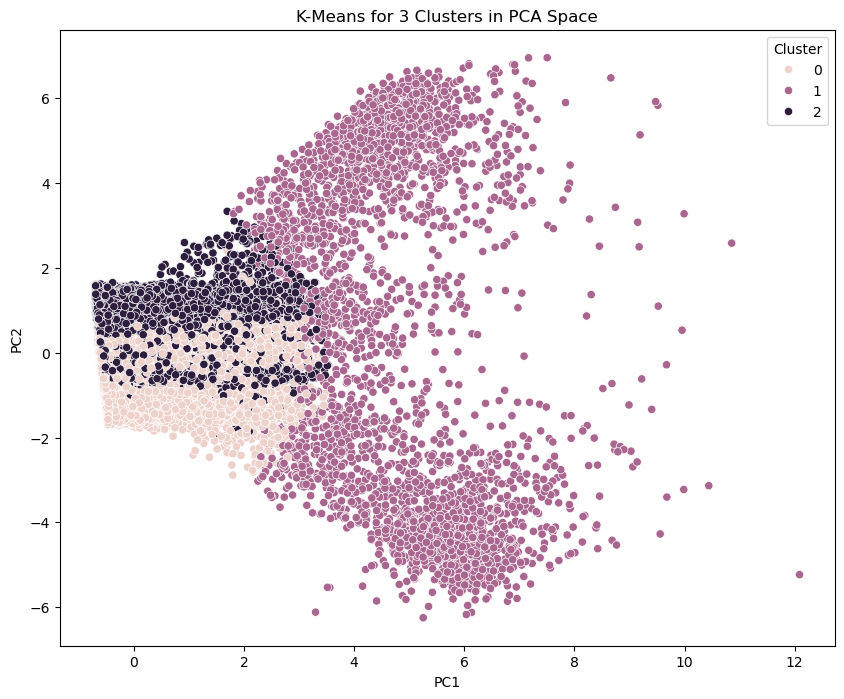

In [7]:
pipe.set_params(kmeans__n_clusters=3)
pipe.fit(X)

labels = pipe.named_steps['kmeans'].labels_
pre_snap["clusterk3"] = labels

X_pca = pipe.named_steps['pca'].transform(pipe.named_steps['scaler'].transform(X))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels)
plt.title("K-Means for 3 Clusters in PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")
plt.show()

In [8]:
cluster3_summary = pre_snap.groupby("clusterk3")[feature_columns].mean()
print(cluster3_summary)

             x_clean    y_clean   s_clean   a_clean     o_clean   dir_clean  \
clusterk3                                                                     
0          54.395197  28.127914  0.077076  0.305572  340.711888  179.270943   
1          53.696504  26.894491  4.867408  2.003395  182.616702  182.683726   
2          54.267017  25.464344  0.078636  0.306333   19.402763  180.628062   

                v_x       v_y  
clusterk3                      
0          0.001691 -0.004482  
1         -0.065523 -0.124270  
2          0.000603  0.005609  


# t-sne, umap

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
import umap.umap_ as umap

In [26]:
positions = pre_snap["player_position"].values # assign labels 
roles = pre_snap["player_role"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# take sample because t-sne and umap are slow

n_sample = min(5000, len(X_scaled)) 
sample_idx = np.random.choice(len(X_scaled), n_sample, replace=False)
X_sample = X_scaled[sample_idx]
positions_sample = positions[sample_idx]
roles_sample = roles[sample_idx]


tsne = TSNE(
    n_components=2, 
    init="pca", 
    learning_rate="auto", 
    random_state=42
).fit_transform(X_sample)

umap_result = umap.UMAP(
    n_components=2, 
    random_state=42
).fit_transform(X_sample)

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [28]:
tsne_df = pd.DataFrame({
    'tsne1': tsne[:, 0],
    'tsne2': tsne[:, 1],
    'position': positions_sample,
    'role': roles_sample
})

umap_df = pd.DataFrame({
    'umap1': umap_result[:, 0],
    'umap2': umap_result[:, 1],
    'position': positions_sample,
    'role': roles_sample
})

In [29]:
tsne_df.head()

,tsne1,tsne2,position,role
0,-27.729683,37.832767,WR,Targeted Receiver
1,19.529154,38.299217,WR,Other Route Runner
2,45.445110,22.259655,QB,Passer
3,19.310493,3.519994,WR,Other Route Runner
4,4.819965,22.953640,TE,Other Route Runner


In [30]:
umap_df.head()

,umap1,umap2,position,role
0,2.333175,9.391179,WR,Targeted Receiver
1,0.913659,10.350657,WR,Other Route Runner
2,-1.514589,10.832649,QB,Passer
3,5.095427,9.024852,WR,Other Route Runner
4,1.385595,7.958458,TE,Other Route Runner


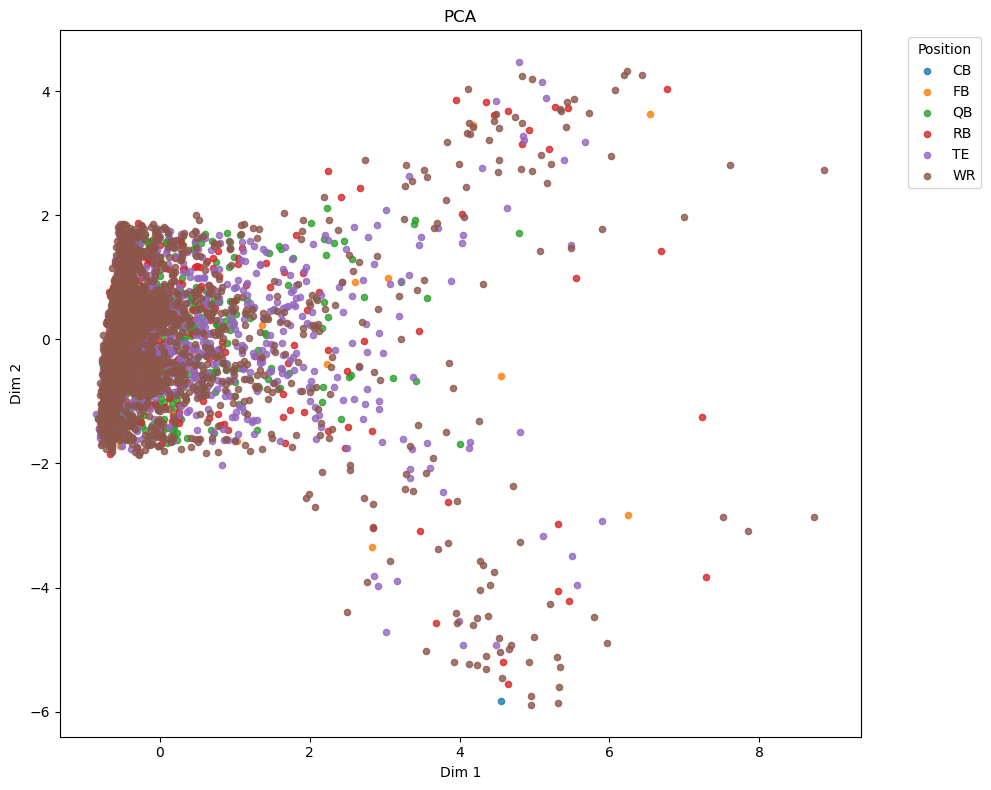

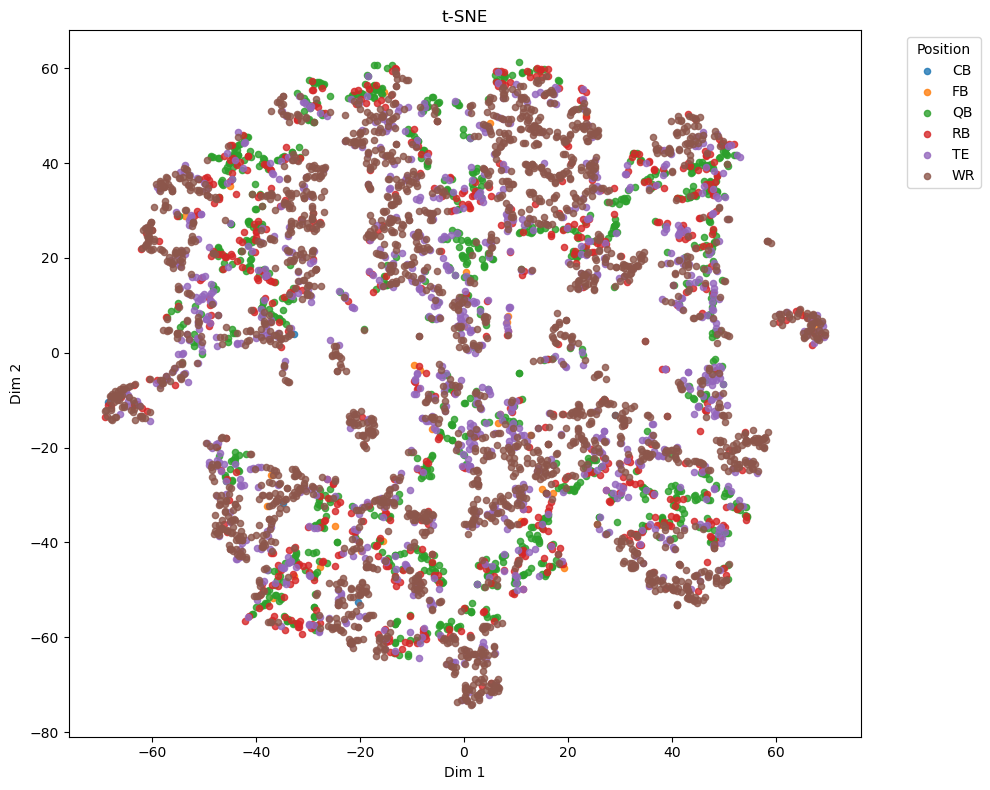

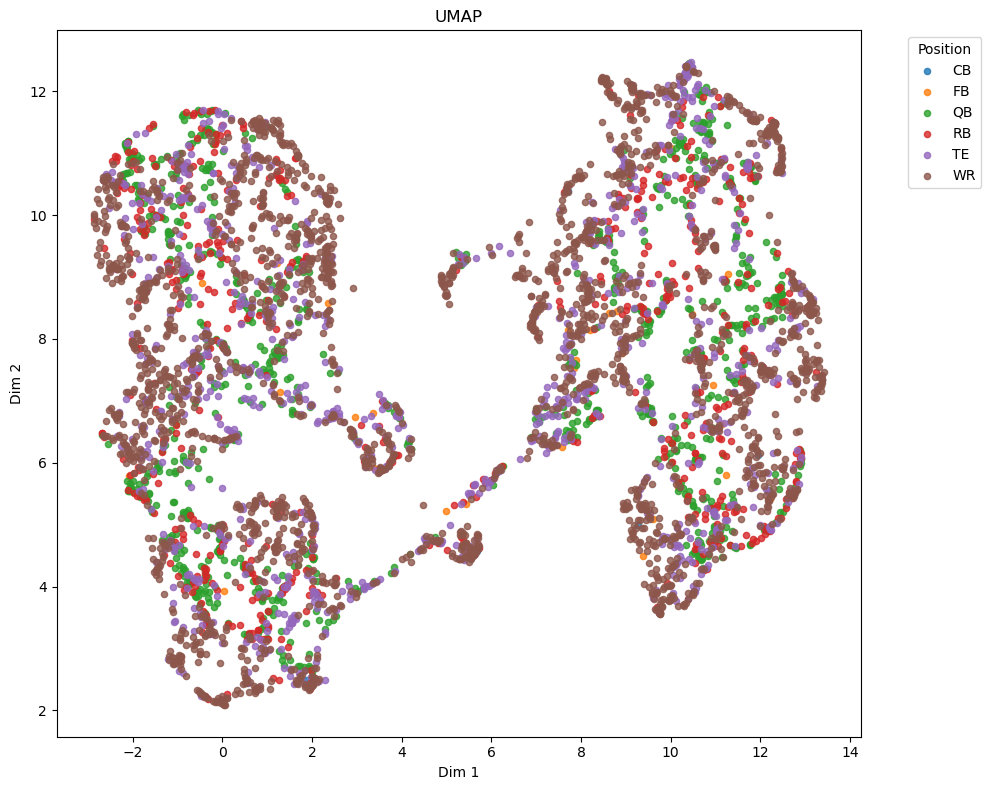

In [32]:
pca = PCA(n_components=2, random_state=42).fit_transform(X_sample)

for emb, title in zip([pca, tsne, umap_result], ["PCA", "t-SNE", "UMAP"]):
    plt.figure(figsize=(10, 8))
    uniq = np.unique(positions_sample)
    for pos in uniq:
        mask = positions_sample == pos
        plt.scatter(emb[mask, 0], emb[mask, 1], s=20, alpha=0.8, label=pos)
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.title(title)
    plt.legend(title="Position", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

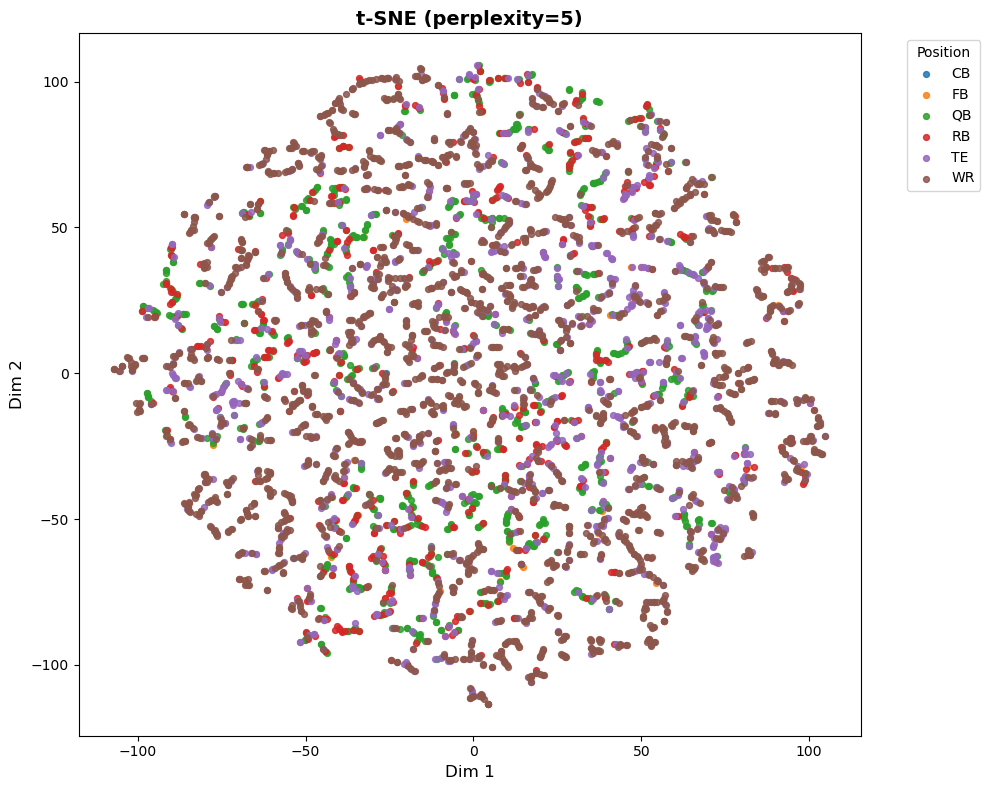

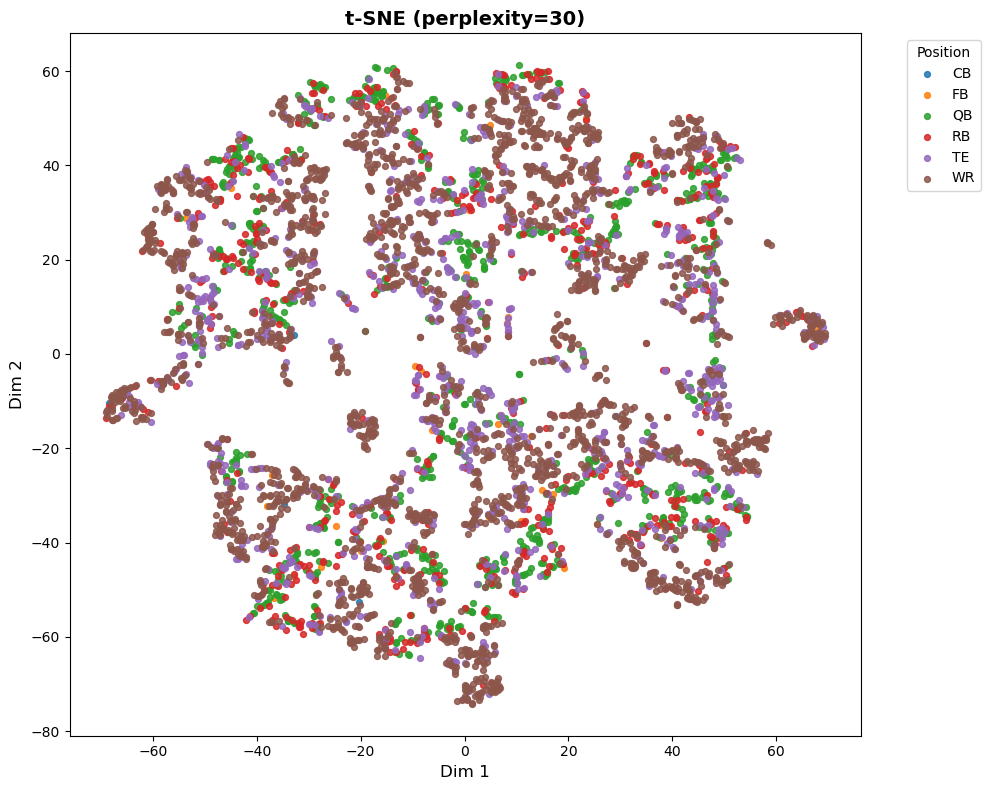

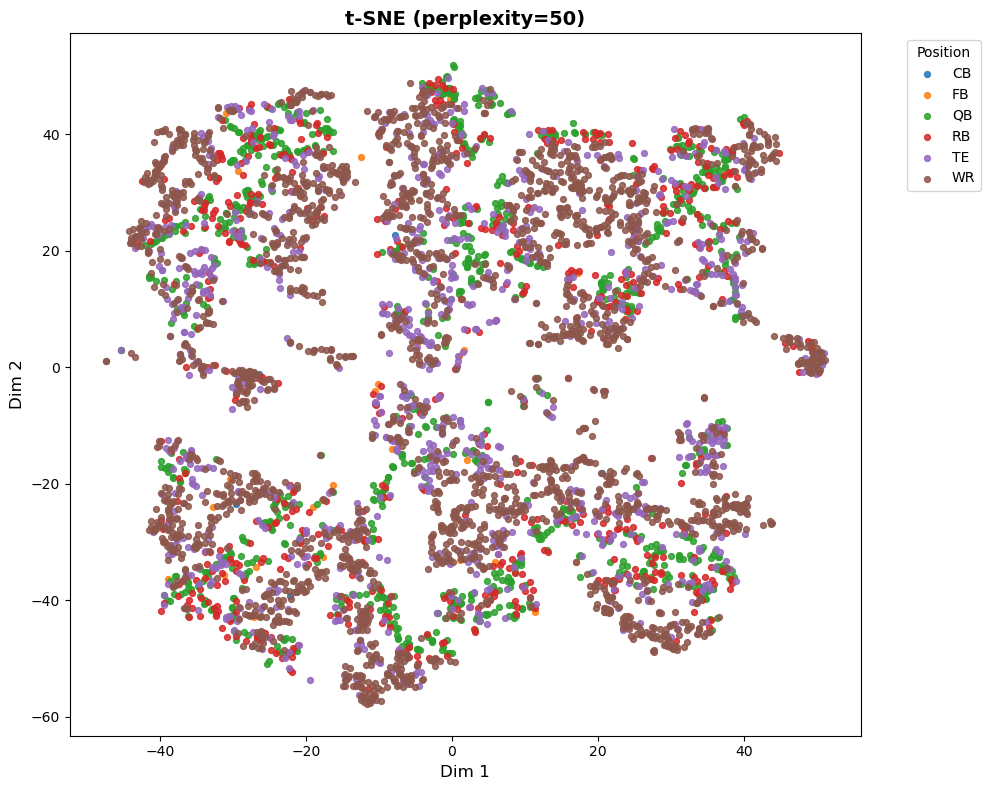

In [33]:
# tuning perplexity for t-sne

def scatter_by_position(emb, title):
    plt.figure(figsize=(10, 8))
    for pos in np.unique(positions_sample):
        m = positions_sample == pos
        plt.scatter(emb[m, 0], emb[m, 1], s=18, alpha=0.85, label=pos)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Dim 1", fontsize=12)
    plt.ylabel("Dim 2", fontsize=12)
    plt.legend(title="Position", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

for perp in [5, 30, 50]:
    emb = TSNE(n_components=2, perplexity=perp, init="pca", learning_rate="auto", random_state=42).fit_transform(X_sample)
    scatter_by_position(emb, f"t-SNE (perplexity={perp})")

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


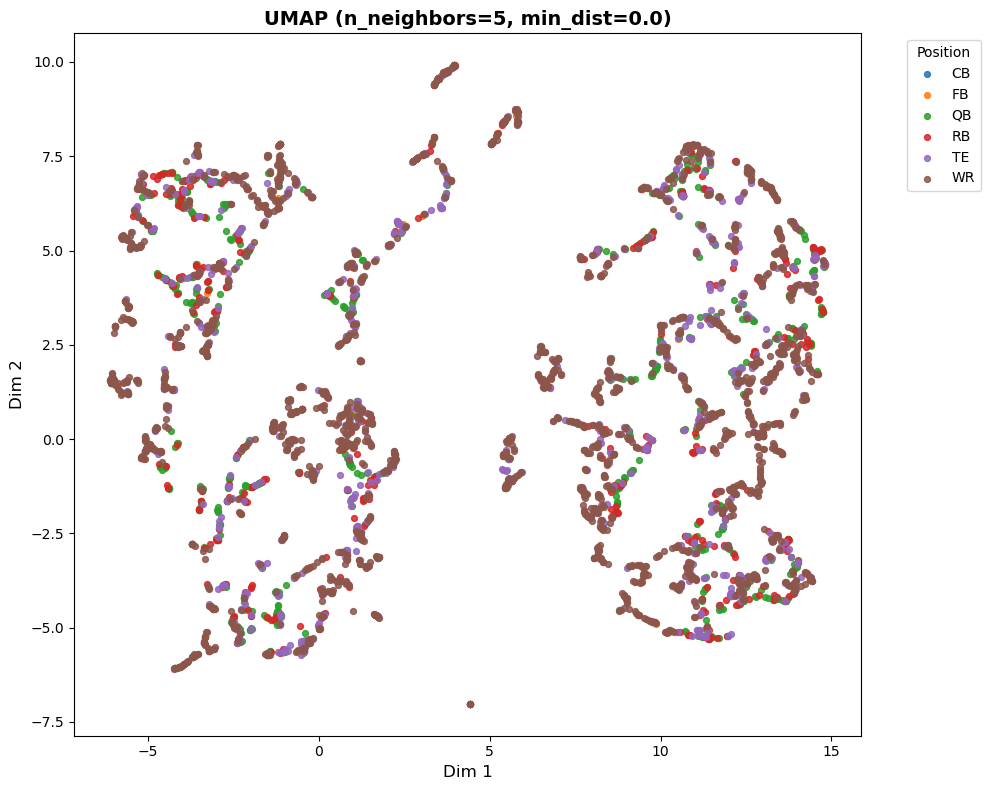

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


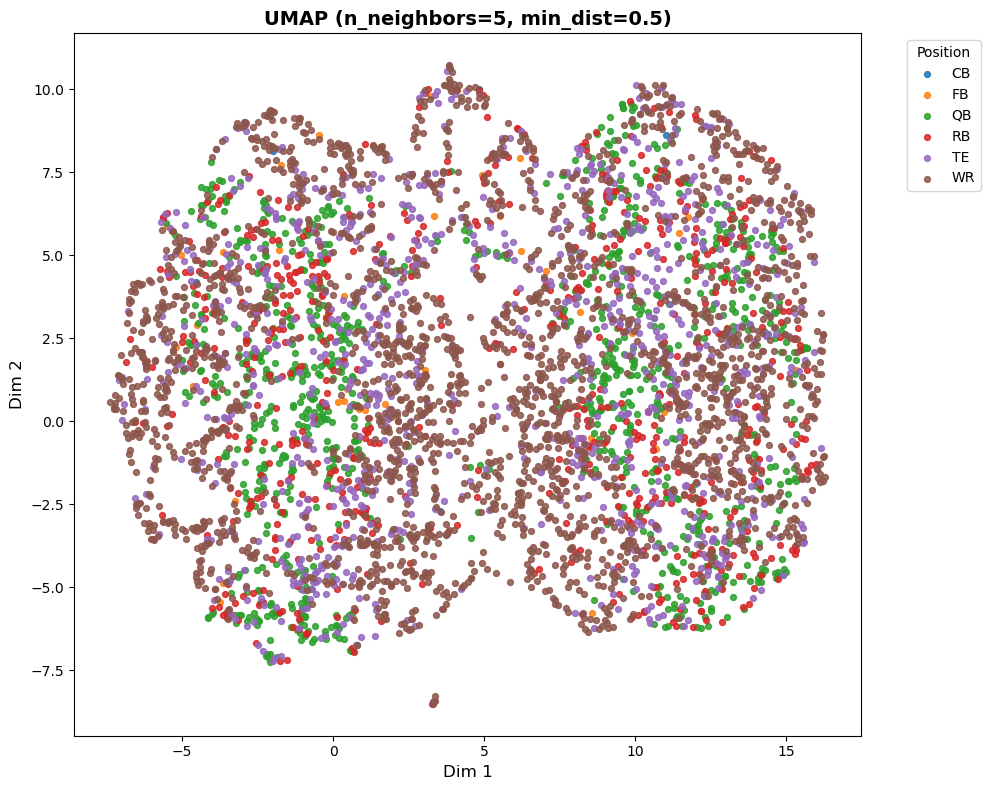

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


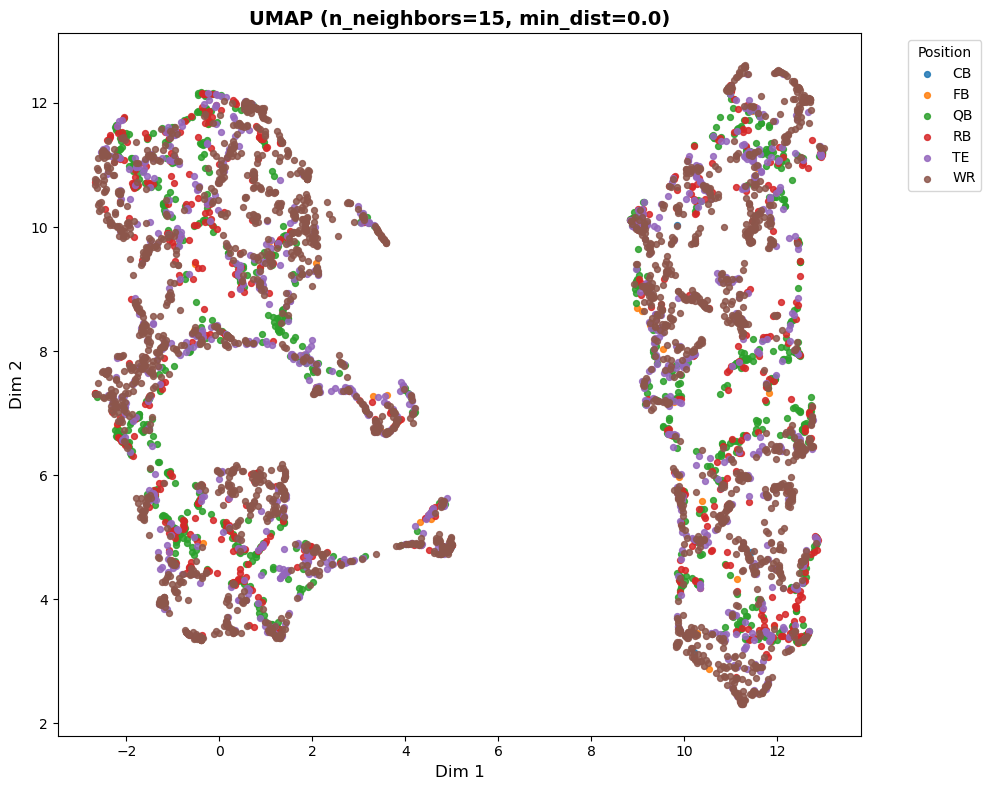

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


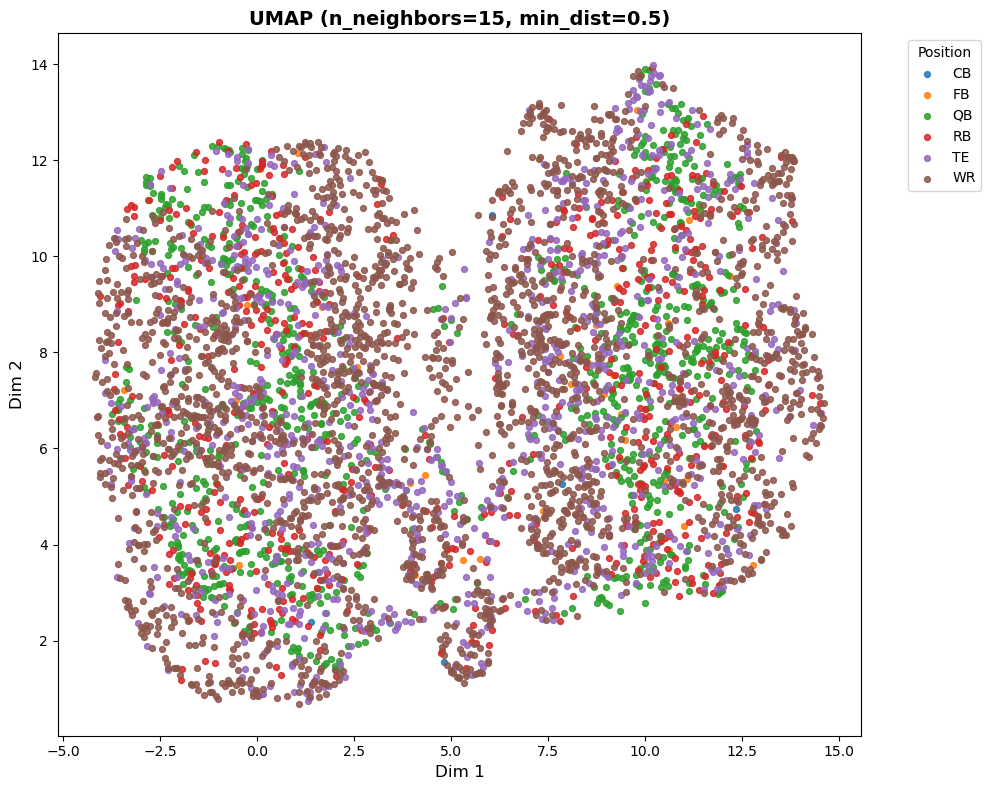

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


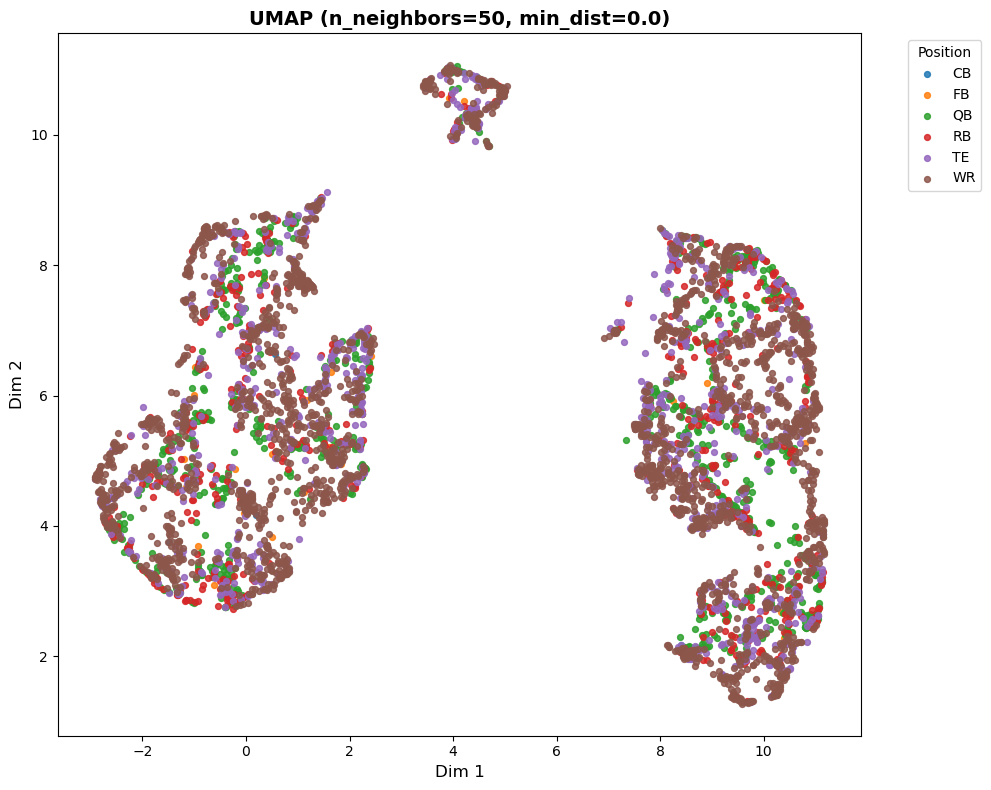

/opt/miniconda3/envs/ds6001/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


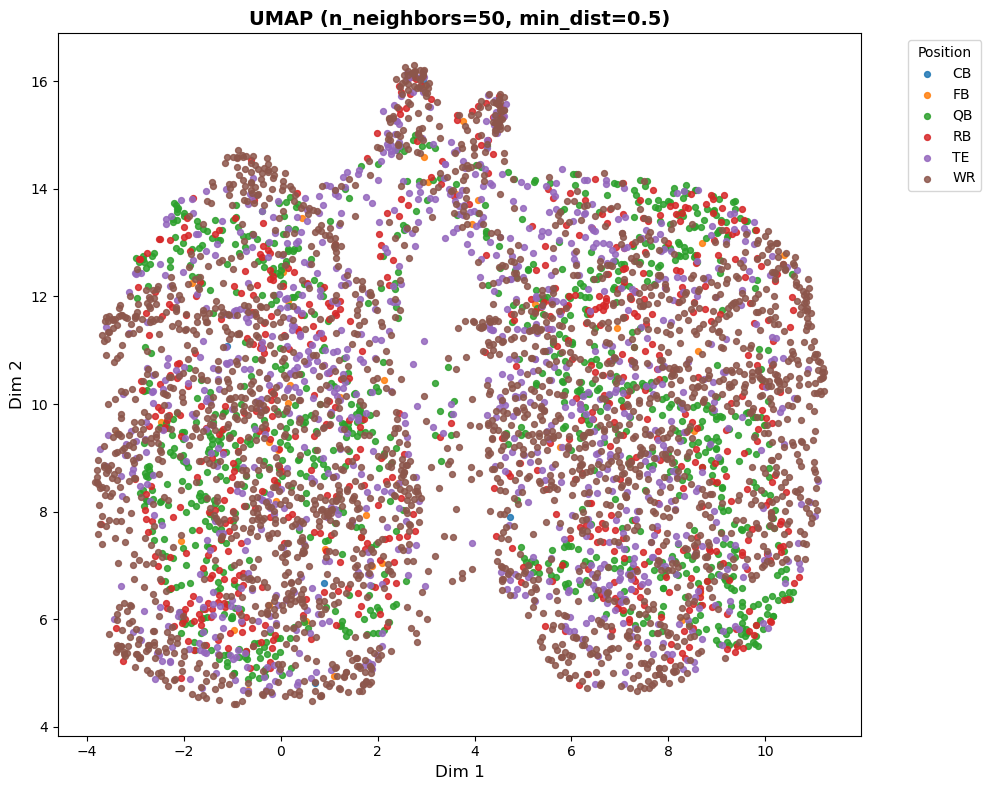

In [34]:
# tuning n_neighbors for umap

for nn in [5, 15, 50]:
    for md in [0.0, 0.5]:
        emb = umap.UMAP(n_components=2, n_neighbors=nn, min_dist=md, random_state=42).fit_transform(X_sample)
        scatter_by_position(emb, f"UMAP (n_neighbors={nn}, min_dist={md})")

# PCR

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression

In [ ]:
features = ['prev_x', 'prev_y', 'o_clean', 'dir_radians', 's_clean', 'a_clean', 'v_x', 'v_y']
X = offense[features].values
y = offense['x_clean'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

pcr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=3)),
    ("linreg", LinearRegression())
])

pcr_pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'


In [17]:
train_r2 = pcr_pipe.score(X_train, y_train)
test_r2  = pcr_pipe.score(X_test, y_test)


y_train_pred = pcr_pipe.predict(X_train)
y_test_pred  = pcr_pipe.predict(X_test)


In [18]:
train_rmse = np.sqrt(np.mean((y_train - y_train_pred)**2))
test_rmse  = np.sqrt(np.mean((y_test - y_test_pred)**2))

print(f"Using n_components = {4}")
print(f"Train R²  : {train_r2:.4f}")
print(f"Test  R²  : {test_r2:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test  RMSE: {test_rmse:.4f}")

Using n_components = 4
Train R²  : 0.3565
Test  R²  : 0.3562
Train RMSE: 18.8302
Test  RMSE: 18.8423


In [ ]:
pca_model = pcr_pipe.named_steps['pca']
print(f"\nExplained variance by 3 PCs: {pca_model.explained_variance_ratio_.sum():.4f}")
print(f"Single PC variance: {pca_model.explained_variance_ratio_}")


Explained variance by 3 PCs: 0.5007
Individual PC variance: [0.2254855  0.14439107 0.13079704]


# Cluster Interpretations